In [1]:
import pandas as pd
from mEncoder import (
    fig_dir
)
import matplotlib.pyplot as plt
import matplotlib

MODEL = 'EGFR_MAPK'
DATA = 'dream_cytof'
SAMPLES = '0_5'

outdir = fig_dir / MODEL / DATA

%matplotlib inline

In [2]:
dfs = []

for dataset in ['train', 'test']:
    pretraining = pd.read_csv(outdir / f'{SAMPLES}_evaluate_pretraining_cross_sample_{dataset}.csv', index_col=[0])
    training = pd.read_csv(outdir / f'{SAMPLES}_evaluate_training_{dataset}.csv', index_col=[0])
    

    dfd = pd.concat([training, pretraining])
    dfd = dfd[dfd['sample'].apply(lambda x: x.endswith('_dyn'))]
    dfd['dataset'] = dataset
    dfs.append(dfd)
    
df = pd.concat(dfs).reset_index()

In [3]:
df

,index,chi2,llh,sample,type,alpha,layers,dataset
0,0,130.229428,-182.865000,cEVSAT_dyn,full,0.0,2,train
1,2,42.733850,-142.812911,cHBL100_dyn,full,0.0,2,train
2,4,85.718182,-119.656377,cHCC1187_dyn,full,0.0,2,train
3,6,39.062534,-152.946894,cHCC1395_dyn,full,0.0,2,train
4,8,38.858342,-112.421997,cHCC1419_dyn,full,0.0,2,train
...,...,...,...,...,...,...,...,...
1315,274,553.081858,-418.852822,cCAL148_dyn,cross_sample,2.0,6,test
1316,276,354.725590,-298.077709,cCAL851_dyn,cross_sample,2.0,6,test
1317,278,153.792656,-181.196839,cCAL51_dyn,cross_sample,2.0,6,test
1318,280,555.918787,-423.202087,cDU4475_dyn,cross_sample,2.0,6,test


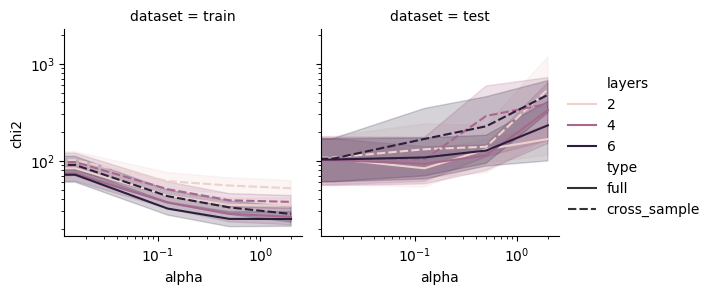

In [5]:
import seaborn as sns

g = sns.FacetGrid(data=df, col='dataset')
g.map_dataframe(sns.lineplot, x='alpha', y='chi2', hue='layers', style='type')
g.set(yscale='log', xscale='log')
g.add_legend()